# Figure 2: Structural model quality

Generates five separate panels for combining in Keynote:

- **Panel A**: PyMOL render of a representative *high template identity* pair (crystal vs best-score decoy overlay). The "easy" case — a close template was available, the decoy matches the crystal tightly.
- **Panel B**: PyMOL render of a representative *low template identity* pair. The headline case — the threading template was distant from the native peptide, yet the decoy still matches the crystal well.
- **Panel C**: PyMOL render of an *outlier* (RMSD > 2 Å). Honest about where the protocol struggles.
- **Panel D**: RMSD distribution histograms (best-score, top-5 mean, min-of-25).
- **Panel E**: Template identity vs best-score RMSD scatter.

The three PyMOL panels are rendered by hand in PyMOL GUI from the `.pml` scripts already generated by notebook 03 — this notebook only documents which pair was selected for each tier and where its `.pml` lives. The matplotlib panels (D, E) are produced here with publication-grade styling matching Figure 1.

Each panel saves as a separate PNG (300 dpi) and PDF, sized for *Scientific Data* dimensions. Combine in Keynote with panel letters added in 14 pt bold.

## Setup

In [1]:
from __future__ import annotations

import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Paths ===
HF_DIR   = Path('/home/huntek1/main_project/data/IEDB_data_clean/huggingface')
DATA_DIR = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/01_structural_regen')
FIG_DIR  = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure2_panels')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# === Figure sizing (Scientific Data conventions) ===
MM = 1 / 25.4   # mm to inches
COL1_WIDTH = 89  * MM     # ~3.5 in single-column
COL2_WIDTH = 183 * MM     # ~7.2 in double-column

# === Plot style (matches Figure 1) ===
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       9,
    'axes.labelsize':  9,
    'axes.titlesize':  10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth':  0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'savefig.dpi':     300,
    'savefig.bbox':    'tight',
})

# === Shared color palette ===
ACCENT_BLUE = '#4477AA'   # primary data color (Tol palette)
ACCENT_RED  = '#CC3311'   # reference lines / thresholds
TREND_GREY  = '#333333'   # trend lines
GRID_GREY   = '#dddddd'   # background grid

## Load validation results

In [2]:
rmsd_df = pd.read_csv(DATA_DIR / 'rmsd_per_pair.csv')

with open(DATA_DIR / 'summary_statistics.json') as f:
    summary = json.load(f)

print(f'Pairs in rmsd_per_pair.csv: {len(rmsd_df):,}')
print()
print('Summary statistics (from notebook 01):')
for metric in ('rmsd_best_score', 'rmsd_top5_mean', 'rmsd_min_of_25'):
    s = summary[metric]
    print(f'  {metric:20s} median = {s["median"]:.2f} Å, <2 Å: {s["pct_lt_2"]:.0f}%')

Pairs in rmsd_per_pair.csv: 52

Summary statistics (from notebook 01):
  rmsd_best_score      median = 1.14 Å, <2 Å: 88%
  rmsd_top5_mean       median = 1.15 Å, <2 Å: 88%
  rmsd_min_of_25       median = 0.92 Å, <2 Å: 92%


## Panel A: High template identity exemplar

A pair from the high-identity tier (template identity ≥ 80%) showing crystal vs best-score decoy peptide. The "easy" case — close templates were available and the modeling matches tightly. Sets the visual baseline for the comparison.

Pair selection: pick from `figure2_panels/high_identity/` (one `.pml` per pair). Open in PyMOL GUI, orient, ray-trace, save as PNG in the same directory.

**Change `PANEL_A_ALLELE` and `PANEL_A_PEPTIDE` to feature a different high-identity pair.**

In [3]:
# ===== Pair selection for Panel A =====
PANEL_A_ALLELE  = "A*02:01"
PANEL_A_PEPTIDE = "GILGFVFTL"   # change as desired

# Look up the pair's stats so we have them in one place for the caption
row_A = rmsd_df[
    (rmsd_df["allele"]  == PANEL_A_ALLELE) &
    (rmsd_df["peptide"] == PANEL_A_PEPTIDE)
]
if len(row_A) == 0:
    raise ValueError(f"Pair {PANEL_A_ALLELE}/{PANEL_A_PEPTIDE} not in rmsd_per_pair.csv")
row_A = row_A.iloc[0]

# Locate the .pml (generated by notebook 03)
def allele_to_safe(a):
    return a.replace("HLA-", "").replace("*", "").replace(":", "")

panel_A_pml = FIG_DIR / "high_identity" / f"high_identity_{allele_to_safe(PANEL_A_ALLELE)}_{PANEL_A_PEPTIDE}.pml"
panel_A_png = FIG_DIR / f"panel_A_high_identity_{PANEL_A_PEPTIDE}.png"

print(f"Panel A:")
print(f"  Pair:               {PANEL_A_ALLELE} / {PANEL_A_PEPTIDE}")
print(f"  Crystal PDB:        {row_A['matched_pdb_id']}")
print(f"  Template identity:  {row_A['template_identity']:.1f}%")
print(f"  Best-score RMSD:    {row_A['rmsd_best_score']:.2f} Å")
print(f"  Min-of-25 RMSD:     {row_A['rmsd_min_of_25']:.2f} Å")
print(f"  PML script:         {panel_A_pml}")
print(f"  Save rendered PNG:  {panel_A_png}")
print(f"  Exists: {panel_A_pml.exists()}")

Panel A:
  Pair:               A*02:01 / GILGFVFTL
  Crystal PDB:        1OGA
  Template identity:  88.9%
  Best-score RMSD:    1.54 Å
  Min-of-25 RMSD:     0.81 Å
  PML script:         /home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure2_panels/high_identity/high_identity_A0201_GILGFVFTL.pml
  Save rendered PNG:  /home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure2_panels/panel_A_high_identity_GILGFVFTL.png
  Exists: True


### Render Panel A in PyMOL

1. `pymol /path/to/figure2_panels/high_identity/high_identity_<allele>_<peptide>.pml`
2. Orient by hand in the GUI (suggested: canonical pHLA cleft view with peptide horizontal, slight forward tilt ~25°).
3. In the PyMOL command bar:
   ```
   ray 2400, 1800
   png /path/to/figure2_panels/panel_A_high_identity_<peptide>.png, dpi=300
   ```
4. Crop the saved PNG to remove the α₃-domain loops at the bottom (PIL or Photoshop). Save back with the same filename.

**Tip:** save the camera matrix with `get_view` after orienting the first panel, and reuse it for Panels B and C so all three share the same viewpoint. The MHC chains are aligned across pairs by the `cealign` step in each `.pml`, so a saved view applies identically.

## Panel B: Low template identity exemplar

The headline case — template identity ≤ 35% but RMSD ≤ 2 Å. Demonstrates that structural quality is not dependent on having a close template, i.e., the pipeline is genuinely modeling the peptide rather than recapitulating a similar template.

Pair selection: pick from `figure2_panels/low_identity/`.

In [4]:
# ===== Pair selection for Panel B =====
PANEL_B_ALLELE  = "A*02:01"
PANEL_B_PEPTIDE = "GMSRIGMEV"   # change as desired

row_B = rmsd_df[
    (rmsd_df["allele"]  == PANEL_B_ALLELE) &
    (rmsd_df["peptide"] == PANEL_B_PEPTIDE)
]
if len(row_B) == 0:
    raise ValueError(f"Pair {PANEL_B_ALLELE}/{PANEL_B_PEPTIDE} not in rmsd_per_pair.csv")
row_B = row_B.iloc[0]

panel_B_pml = FIG_DIR / "low_identity" / f"low_identity_{allele_to_safe(PANEL_B_ALLELE)}_{PANEL_B_PEPTIDE}.pml"
panel_B_png = FIG_DIR / f"panel_B_low_identity_{PANEL_B_PEPTIDE}.png"

print(f"Panel B:")
print(f"  Pair:               {PANEL_B_ALLELE} / {PANEL_B_PEPTIDE}")
print(f"  Crystal PDB:        {row_B['matched_pdb_id']}")
print(f"  Template identity:  {row_B['template_identity']:.1f}%")
print(f"  Best-score RMSD:    {row_B['rmsd_best_score']:.2f} Å")
print(f"  Min-of-25 RMSD:     {row_B['rmsd_min_of_25']:.2f} Å")
print(f"  PML script:         {panel_B_pml}")
print(f"  Save rendered PNG:  {panel_B_png}")
print(f"  Exists: {panel_B_pml.exists()}")

Panel B:
  Pair:               A*02:01 / GMSRIGMEV
  Crystal PDB:        7KGP
  Template identity:  33.3%
  Best-score RMSD:    1.05 Å
  Min-of-25 RMSD:     1.05 Å
  PML script:         /home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure2_panels/low_identity/low_identity_A0201_GMSRIGMEV.pml
  Save rendered PNG:  /home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure2_panels/panel_B_low_identity_GMSRIGMEV.png
  Exists: True


### Render Panel B in PyMOL

Same procedure as Panel A. Use the saved view matrix from Panel A so the orientation matches:

```
ray 2400, 1800
png /path/to/figure2_panels/panel_B_low_identity_<peptide>.png, dpi=300
```

Then crop to match Panel A's framing.

## Panel C: Outlier exemplar

A failure case — RMSD > 2 Å — to be honest about where the protocol struggles. Typically these are longer peptides or pairs where the threading template diverged badly.

Pair selection: pick from `figure2_panels/outliers/`.

In [5]:
# ===== Pair selection for Panel C =====
PANEL_C_ALLELE  = "A*02:01"
PANEL_C_PEPTIDE = "LLFNILGGWV"   # change as desired

row_C = rmsd_df[
    (rmsd_df["allele"]  == PANEL_C_ALLELE) &
    (rmsd_df["peptide"] == PANEL_C_PEPTIDE)
]
if len(row_C) == 0:
    raise ValueError(f"Pair {PANEL_C_ALLELE}/{PANEL_C_PEPTIDE} not in rmsd_per_pair.csv")
row_C = row_C.iloc[0]

panel_C_pml = FIG_DIR / "outliers" / f"outliers_{allele_to_safe(PANEL_C_ALLELE)}_{PANEL_C_PEPTIDE}.pml"
panel_C_png = FIG_DIR / f"panel_C_outlier_{PANEL_C_PEPTIDE}.png"

print(f"Panel C:")
print(f"  Pair:               {PANEL_C_ALLELE} / {PANEL_C_PEPTIDE}")
print(f"  Crystal PDB:        {row_C['matched_pdb_id']}")
print(f"  Template identity:  {row_C['template_identity']:.1f}%")
print(f"  Best-score RMSD:    {row_C['rmsd_best_score']:.2f} Å")
print(f"  Min-of-25 RMSD:     {row_C['rmsd_min_of_25']:.2f} Å")
print(f"  PML script:         {panel_C_pml}")
print(f"  Save rendered PNG:  {panel_C_png}")
print(f"  Exists: {panel_C_pml.exists()}")

Panel C:
  Pair:               A*02:01 / LLFNILGGWV
  Crystal PDB:        3MRN
  Template identity:  30.0%
  Best-score RMSD:    2.78 Å
  Min-of-25 RMSD:     2.65 Å
  PML script:         /home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure2_panels/outliers/outliers_A0201_LLFNILGGWV.pml
  Save rendered PNG:  /home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure2_panels/panel_C_outlier_LLFNILGGWV.png
  Exists: True


### Render Panel C in PyMOL

Same procedure as Panels A and B, same view matrix:

```
ray 2400, 1800
png /path/to/figure2_panels/panel_C_outlier_<peptide>.png, dpi=300
```

## Panel D: RMSD distribution histograms

Three side-by-side histograms: best-score decoy RMSD, mean RMSD of top-5 by score, and minimum RMSD across all 25 decoys. The 2 Å dashed line marks the conventional "near-native" threshold.

/tmp/ipykernel_2961850/1945928569.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


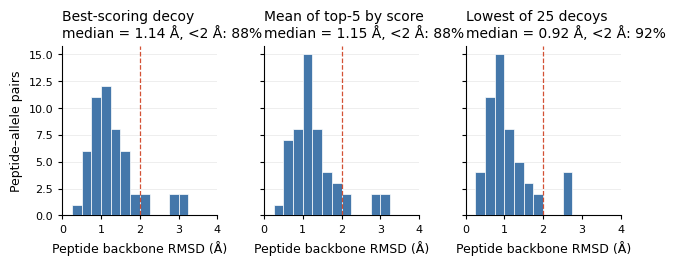

In [6]:
metrics = [
    ('rmsd_best_score', 'Best-scoring decoy'),
    ('rmsd_top5_mean',  'Mean of top-5 by score'),
    ('rmsd_min_of_25',  'Lowest of 25 decoys'),
]

bins = np.arange(0, 10.1, 0.25)
fig, axes = plt.subplots(1, 3, figsize=(COL2_WIDTH, 2.2),
                         sharey=True, gridspec_kw={'wspace': 0.30})

for ax, (col, label) in zip(axes, metrics):
    vals = rmsd_df[col].values

    ax.hist(vals, bins=bins, color=ACCENT_BLUE,
            edgecolor='white', linewidth=0.5, zorder=3)
    ax.axvline(2.0, color=ACCENT_RED, linestyle='--',
               linewidth=0.9, alpha=0.85, zorder=4)

    # Light background grid
    ax.yaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

    # Title and stats
    median = np.median(vals)
    pct_lt_2 = (vals < 2.0).mean() * 100
    ax.set_title(f'{label}\nmedian = {median:.2f} Å, <2 Å: {pct_lt_2:.0f}%',
                 loc='left')

    ax.set_xlabel('Peptide backbone RMSD (Å)')
    ax.set_xlim(0, 4)

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3)

axes[0].set_ylabel('Peptide–allele pairs')

fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_D_rmsd_distributions.png')
fig.savefig(FIG_DIR / 'panel_D_rmsd_distributions.pdf')
plt.show()

## Panel E: Template identity vs best-score RMSD

Scatter of best-score decoy RMSD against threading-template identity to the native peptide, with linear trendline and Spearman correlation. Low/flat trend (no strong correlation) supports the claim that modeling quality is not dependent on close templates.

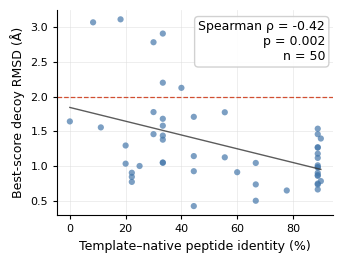

In [7]:
from scipy.stats import spearmanr

valid = rmsd_df.dropna(subset=['template_identity', 'rmsd_best_score'])
rho_result = spearmanr(valid['template_identity'], valid['rmsd_best_score'])
rho, pval, n = rho_result.statistic, rho_result.pvalue, len(valid)
p_str = 'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'

fig, ax = plt.subplots(figsize=(COL1_WIDTH, 2.7))

ax.scatter(valid['template_identity'], valid['rmsd_best_score'],
           alpha=0.7, s=20, color=ACCENT_BLUE, zorder=3, edgecolor='none')

# Linear trendline
x = valid['template_identity'].values
y = valid['rmsd_best_score'].values
slope, intercept = np.polyfit(x, y, 1)
x_line = np.array([x.min(), x.max()])
ax.plot(x_line, slope * x_line + intercept,
        color=TREND_GREY, linewidth=1.0, alpha=0.8, zorder=4)

# 2 Å reference line
ax.axhline(2.0, color=ACCENT_RED, linestyle='--',
           linewidth=0.9, alpha=0.85, zorder=2)

# Light background grid
ax.yaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
ax.xaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

# Correlation annotation
ax.text(0.97, 0.95,
        f'Spearman ρ = {rho:.2f}\n{p_str}\nn = {n}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', edgecolor='#cccccc', alpha=0.9))

ax.set_xlabel('Template–native peptide identity (%)')
ax.set_ylabel('Best-score decoy RMSD (Å)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', length=3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_E_template_identity_scatter.png')
fig.savefig(FIG_DIR / 'panel_E_template_identity_scatter.pdf')
plt.show()

## Combined figure

Lays out all panels (A, B, C blank for PyMOL renders; D1/D2/D3 RMSD histograms; E template-identity scatter) into a single figure for direct export. Mirrors the structure of Figure 1's combined cell.

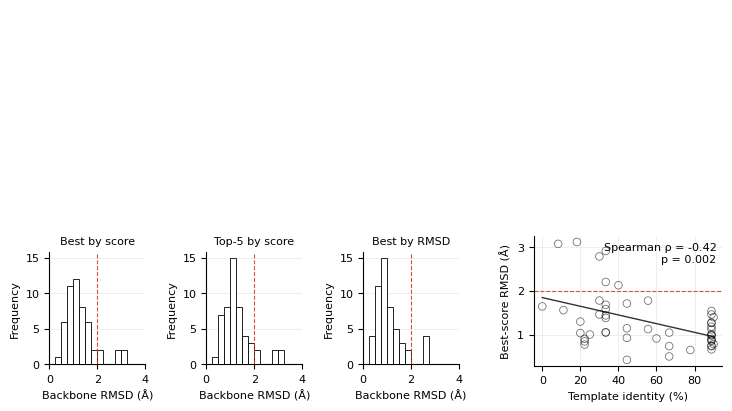

In [8]:
import matplotlib.lines as mlines
from scipy.stats import spearmanr

# ============== LAYOUT KNOBS (edit these) ==============
FONT_SIZE             = 8
TOP_ROW_H             = 2.25
BOTTOM_ROW_H          = 1.75
TOP_WIDTH_RATIOS      = [1, 1, 1]
BOTTOM_WIDTH_RATIOS   = [2, 1]
HIST_WIDTH_RATIOS     = [1, 1, 1]
HIST_WSPACE           = 0.075
SUBFIG_WSPACE         = 0.075
RMSD_XLIM             = (0, 4)
RMSD_BINWIDTH         = 0.25
SCATTER_POINT_SIZE    = 30
SCATTER_ALPHA         = 0.55
THRESHOLD_COLOR       = '#CC3311'    # red for 2 Å reference line
# =======================================================

plt.rcParams.update({
    'font.size':         FONT_SIZE,
    'axes.labelsize':    FONT_SIZE,
    'axes.titlesize':    FONT_SIZE,
    'xtick.labelsize':   FONT_SIZE,
    'ytick.labelsize':   FONT_SIZE,
    'legend.fontsize':   FONT_SIZE,
})

fig = plt.figure(figsize=(COL2_WIDTH, TOP_ROW_H + BOTTOM_ROW_H), constrained_layout=True)
top, bottom = fig.subfigures(2, 1, height_ratios=[TOP_ROW_H, BOTTOM_ROW_H])

ax_A, ax_B, ax_C = top.subplots(1, 3, width_ratios=TOP_WIDTH_RATIOS)

left, right = bottom.subfigures(1, 2, width_ratios=BOTTOM_WIDTH_RATIOS, wspace=0.08)
ax_D1, ax_D2, ax_D3 = left.subplots(
    1, 3,
    width_ratios=HIST_WIDTH_RATIOS,
    sharey=True,
    gridspec_kw={'wspace': HIST_WSPACE})
ax_E = right.subplots(1, 1)

def _style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.minorticks_off()
    ax.yaxis.grid(True, color='#dddddd', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

# --- A, B, C: blank for PyMOL renders ---
for ax in (ax_A, ax_B, ax_C):
    ax.axis('off')

# --- D1, D2, D3: RMSD histograms ---
metrics = [
    ('rmsd_best_score', 'Best by score'),
    ('rmsd_top5_mean',  'Top-5 by score'),
    ('rmsd_min_of_25',  'Best by RMSD')]
bins = np.arange(RMSD_XLIM[0], RMSD_XLIM[1] + RMSD_BINWIDTH, RMSD_BINWIDTH)

for ax, (col, label) in zip([ax_D1, ax_D2, ax_D3], metrics):
    vals = rmsd_df[col].values
    ax.hist(vals, bins=bins,
            color='white', edgecolor='black', linewidth=0.6, zorder=3)
    ax.axvline(2.0, color=THRESHOLD_COLOR, linestyle='--',
               linewidth=0.8, alpha=0.85, zorder=4)
    ax.set_title(label)
    ax.set_xlabel('Backbone RMSD (Å)')
    ax.set_xlim(*RMSD_XLIM)
    _style(ax)

for ax in (ax_D2, ax_D3): ax.tick_params(labelleft=True)
ax_D1.set_ylabel('Frequency')
for ax in (ax_D1, ax_D2, ax_D3): ax.set_ylabel('Frequency')

# --- E: template identity vs RMSD ---
valid = rmsd_df.dropna(subset=['template_identity', 'rmsd_best_score'])
rho_result = spearmanr(valid['template_identity'], valid['rmsd_best_score'])
rho, pval, _ = rho_result.statistic, rho_result.pvalue, len(valid)
p_str = 'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'

ax_E.scatter(valid['template_identity'], valid['rmsd_best_score'],
             facecolor='none', edgecolor='black',
             s=SCATTER_POINT_SIZE, linewidth=0.6,
             alpha=SCATTER_ALPHA, zorder=3)

x = valid['template_identity'].values
y = valid['rmsd_best_score'].values
slope, intercept = np.polyfit(x, y, 1)
x_line = np.array([x.min(), x.max()])
ax_E.plot(x_line, slope * x_line + intercept,
          color='black', linewidth=1.0, alpha=0.8, zorder=4)

ax_E.axhline(2.0, color=THRESHOLD_COLOR, linestyle='--',
             linewidth=0.8, alpha=0.85, zorder=2)

ax_E.text(0.97, 0.95,
          f'Spearman ρ = {rho:.2f}\n{p_str}',
          transform=ax_E.transAxes, ha='right', va='top')

ax_E.set_xlabel('Template identity (%)')
ax_E.set_ylabel('Best-score RMSD (Å)')
_style(ax_E)
ax_E.xaxis.grid(True, color='#dddddd', linewidth=0.5, alpha=0.7)

fig.savefig(FIG_DIR / 'figure2_combined.png', dpi=600)
fig.savefig(FIG_DIR / 'figure2_combined.pdf')
plt.show()

## Summary

Panel files in `figure2_panels/`:

- **Individual panels** (used during iteration / debugging):
  - `panel_A_high_identity_<peptide>.png` — PyMOL render (from `high_identity/*.pml`)
  - `panel_B_low_identity_<peptide>.png` — PyMOL render (from `low_identity/*.pml`)
  - `panel_C_outlier_<peptide>.png` — PyMOL render (from `outliers/*.pml`)
  - `panel_D_rmsd_distributions.{png,pdf}`
  - `panel_E_template_identity_scatter.{png,pdf}`

- **Combined figure** (the deliverable):
  - `figure2_combined.{png,pdf}` — all five panels laid out in one figure. The A/B/C cells are blank rectangles; drop the ray-traced PyMOL PNGs into those positions in Keynote/Illustrator.

**Combining in Keynote:**

1. Open `figure2_combined.png` as a slide background.
2. Drop the three PyMOL renders (panel_A/B/C PNGs) into the blank A, B, C slots.
3. Add panel letters (A, B, C, D, E) as separate text boxes, Helvetica/Arial Bold 14 pt, upper-left of each panel.
4. Export: `File → Export To → Image…`, PNG at 300 dpi.